# Preprocessing Flow for Used Car Price Prediction
**Owner:** DOEM Sreypok

This notebook performs the full preprocessing workflow for the used-car dataset:

1. **Import Libraries**
2. **Load Dataset**
3. **Data Cleaning**
4. **Feature Selection**
5. **Feature Engineering**
6. **Encoding & Feature Scaling**
7. **Train-Test Split**
8. **Processed Features**
9. **Save Processed Data**


# 1. Import Libraries

In [228]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

workspace = Path.cwd().resolve().parent
# Prepend src to sys.path so local `preprocess` is found before any installed package
sys.path.insert(0, str(workspace / "src"))

# Import and reload to ensure the notebook kernel picks up the latest `preprocess.py`
import preprocess as _preprocess
importlib.reload(_preprocess)
from preprocess import load_dataset, preprocess_data, save_processed_data


# 2. Load Dataset

In [229]:
df = load_dataset("../data/raw/used_car_sales.csv")

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

print("Training shape :", X_train.shape)
print("Testing shape  :", X_test.shape)
print("Train labels   :", y_train.shape)
print("Test labels    :", y_test.shape)
df.head()

Training shape : (8000, 62)
Testing shape  : (2000, 62)
Train labels   : (8000,)
Test labels    : (2000,)


,ID,Distributor Name,Location,Car Name,Manufacturer Name,Car Type,Color,Gearbox,Number of Seats,Number of Doors,...,Purchased Date,Car Sale Status,Sold Date,Purchased Price-$,Sold Price-$,Margin-%,Sales Agent Name,Sales Rating,Sales Commission-$,Feedback
0,O2KE17,Carmudi,California,Fortuner,Toyota,SUV,Gray,Automatic,8,5,...,2022-10-26,Un Sold,1970-01-01,8296,0,0,Pranav,1,0,Average
1,EPMPC8,Carousell,Philadelphia,Creta,Hyundai,Hatchback,Blue,Automatic,5,5,...,2017-08-25,Sold,2021-03-03,5659,4770,-16,Vihaan,5,0,Good
2,SQKXAP,Carsome,North Carolina,Scorpio,Mahindra,SUV,Gray,Automatic,5,5,...,2018-06-13,Un Sold,1970-01-01,8430,0,0,Aarush,4,0,Good
3,PWP2QK,Trivett,North Carolina,Plato,Prazo,Convertible,Gray,Automatic,2,2,...,2023-05-14,Sold,2024-04-02,6919,7942,15,Anushka,1,205,Average
4,FNDDKM,Zupps,Portland,Dzire,Maruti,Sedan,Red,Automatic,5,5,...,2022-08-24,Un Sold,1970-01-01,6864,0,0,Pavan,3,0,Poor


# 3. Data Cleaning

In [230]:
# 1.  Check Missing Values =========================
missing = df.isnull().sum().sort_values(ascending=False)
missing

ID                    0
Distributor Name      0
Location              0
Car Name              0
Manufacturer Name     0
Car Type              0
Color                 0
Gearbox               0
Number of Seats       0
Number of Doors       0
Energy                0
Manufactured Year     0
Price-$               0
Mileage-KM            0
Engine Power-HP       0
Purchased Date        0
Car Sale Status       0
Sold Date             0
Purchased Price-$     0
Sold Price-$          0
Margin-%              0
Sales Agent Name      0
Sales Rating          0
Sales Commission-$    0
Feedback              0
dtype: int64

In [231]:
# 2.  Check Duplicate Rows =========================
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [232]:
# 3. Rename Columns =========================
df = df.rename(columns={
    "Price-$": "price",
    "Manufactured Year": "year",
    "Mileage-KM": "mileage",
    "Engine Power-HP": "horsepower",
    "Manufacturer Name": "brand",
    "Car Name": "model",
    "Energy": "fuel_type",
    "Gearbox": "transmission",
    "Number of Seats": "number_of_seats",
    "Number of Doors": "number_of_doors",
    "Car Type": "car_type",
    "Car Sale Status": "sale_status"
})

df.columns

Index(['ID', 'Distributor Name', 'Location', 'model', 'brand', 'car_type',
       'Color', 'transmission', 'number_of_seats', 'number_of_doors',
       'fuel_type', 'year', 'price', 'mileage', 'horsepower', 'Purchased Date',
       'sale_status', 'Sold Date', 'Purchased Price-$', 'Sold Price-$',
       'Margin-%', 'Sales Agent Name', 'Sales Rating', 'Sales Commission-$',
       'Feedback'],
      dtype='str')

In [233]:
# 4. Convert Data Type  =========================

numeric_columns = [
    "year",
    "mileage",
    "horsepower",
    "number_of_seats",
    "number_of_doors",
    "price"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

ID                      str
Distributor Name        str
Location                str
model                   str
brand                   str
car_type                str
Color                   str
transmission            str
number_of_seats       int64
number_of_doors       int64
fuel_type               str
year                  int64
price                 int64
mileage               int64
horsepower            int64
Purchased Date          str
sale_status             str
Sold Date               str
Purchased Price-$     int64
Sold Price-$          int64
Margin-%              int64
Sales Agent Name        str
Sales Rating          int64
Sales Commission-$    int64
Feedback                str
dtype: object

# 4. Feature Selection

In [234]:
# Select the features used for prediction.
features = [
    "year",
    "mileage",
    "horsepower",
    "number_of_seats",
    "number_of_doors",
    "brand",
    "model",
    "fuel_type",
    "transmission",
    "Location",
    "car_type",
    "Color",
    "sale_status"
]

features = [f for f in features if f in df.columns]

X = df[features]
y = df["price"]

print("Features:")
print(X.columns.tolist())

Features:
['year', 'mileage', 'horsepower', 'number_of_seats', 'number_of_doors', 'brand', 'model', 'fuel_type', 'transmission', 'Location', 'car_type', 'Color', 'sale_status']


# 5. Feature Engineering

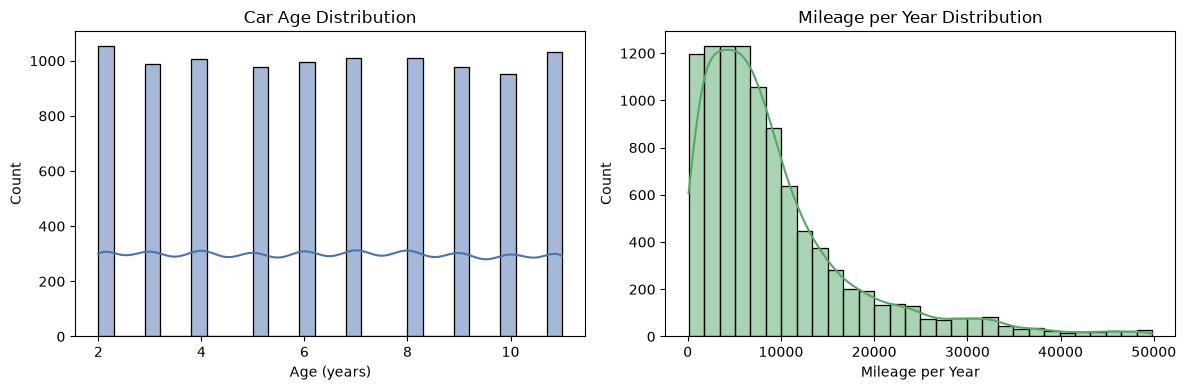

In [235]:
#Create new features: Car Age and Mileage per Year.

current_year = 2026

if "year" in df.columns:
    df["car_age"] = current_year - df["year"]
else:
    df["car_age"] = pd.NA

# Mileage per year: avoid division by zero or missing ages
if "mileage" in df.columns:
    def _mileage_per_year(row):
        try:
            age = row.get("car_age")
            miles = row.get("mileage")
            if pd.isna(miles) or pd.isna(age) or age <= 0:
                return pd.NA
            return miles / age
        except Exception:
            return pd.NA

    df["mileage_per_year"] = df.apply(_mileage_per_year, axis=1)
else:
    df["mileage_per_year"] = pd.NA

df[["year", "car_age", "mileage", "mileage_per_year"]].head()

# Plot distributions for the new features
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["car_age"].dropna(), bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Car Age Distribution")
axes[0].set_xlabel("Age (years)")

sns.histplot(df["mileage_per_year"].dropna(), bins=30, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Mileage per Year Distribution")
axes[1].set_xlabel("Mileage per Year")

plt.tight_layout()
plt.show()


# 6. Encoding & Feature Scaling

In [250]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

In [254]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Numerical features
numeric_features = [
    "year",
    "mileage",
    "engine_size"
]


# Categorical features
categorical_features = [
    "brand",
    "fuel_type",
    "transmission"
]


# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [255]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

# 7. Train-Test Split

- Testing data: used to evaluate model performance

Split the dataset into training and testing sets and verify the distribution.- Training data: used to fit the model


Training Features : (8000, 62)
Testing Features  : (2000, 62)
Training Labels   : (8000,)
Testing Labels    : (2000,)

Training split: 8000 samples (80.0%)
Testing split : 2000 samples (20.0%)


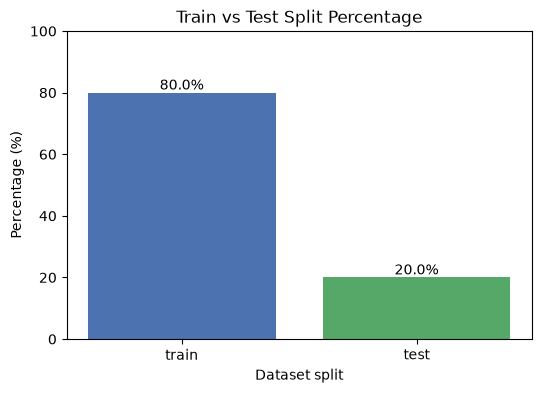

In [239]:
train_count = X_train.shape[0]
test_count = X_test.shape[0]
total_count = train_count + test_count

train_pct = train_count / total_count * 100
test_pct = test_count / total_count * 100

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)
print(f"\nTraining split: {train_count} samples ({train_pct:.1f}%)")
print(f"Testing split : {test_count} samples ({test_pct:.1f}%)")

# Optional split percentage chart
split_data = pd.DataFrame({
    "set": ["train", "test"],
    "count": [train_count, test_count],
    "percentage": [train_pct, test_pct]
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split_data["set"], split_data["percentage"], color=["#4C72B0", "#55A868"])
ax.set_xlabel("Dataset split")
ax.set_ylabel("Percentage (%)")
ax.set_title("Train vs Test Split Percentage")
ax.set_ylim(0, 100)
for i, pct in enumerate(split_data["percentage"]):
    ax.text(i, pct + 1, f"{pct:.1f}%", ha="center")
plt.show()


# 8. Processed Features

In [240]:
processed = pd.DataFrame(X_train[:5].toarray())

processed

,0,1,2,3,4,5,6,7,8,9,...,52,53,54,55,56,57,58,59,60,61
0,0.857356,0.756125,-0.968378,0.145933,0.725482,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.550225,-0.808460,2.382821,-1.899858,-1.642795,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-1.221251,-0.213110,-0.298138,0.145933,-0.853369,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.221251,0.235999,-0.968378,0.145933,0.725482,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.550225,1.533634,2.382821,-1.899858,-1.642795,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# 9. Save processed data

In [241]:

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)
save_processed_data(
    X_train,
    X_test,
    y_train,
    y_test
)



Processed data saved to: /Users/fedora/Desktop/used-car-price-prediction/data/processed


## Summary

1. **Import Libraries**
2. **Load Dataset**
3. **Data Cleaning**
4. **Feature Selection**
5. **Feature Engineering**
6. **Encoding & Feature Scaling**
7. **Train-Test Split**
8. **Processed Features**
9. **Save Processed Data**
